# Descent Types

---
## Purpose
- Classify and analyze particle subduction/descent events from FESOM drifter experiments.
- Produce metrics, time-normalised composites, diagnostic plots and spatial maps by descent-type.

## Data & inputs
- Raw particle NetCDF tracts (files_raw) and subduction CSVs (files_sub).
- Gate / crossing pickles (files_gate) providing drifter→track mapping.
- Subduction csv files (files_sub) providing the timing of subduction of descent per particle.
- Bathymetry and seasonal sea-ice fields for plotting.
- Custom helper modules loaded from local paths (custom_classes, particles_loading, plotting_functions, wedge_map, helper, FESOM_processing, FESOM_plotting).

## Main processing steps
1. Load gate pickles and raw drifter datasets into DS and gate_data.
2. Read and combine subduction CSVs into df_all (unique drifter_idx created per file, drifter_id retained).
3. Filter to subduction + recirculation drifters, loop per drifter:
    - Extract event indices (start, drop, stop, pw).
    - Compute kinematics: duration, total depth gained, mean descent rate.
    - Compute bulk density change, slope, Pearson R between depth and sigma0.
    - Extract dynamic metrics (Ro, strain, divergence, Okubo–Weiss) around drop.
    - Determine mixed-layer membership and percent time in ML.
    - Collect per-drifter records into df_metrics and merge into df_out.
4. Build classification labels using thresholds (r_pear, slope, mean_descent_rate) into categories and color_dict.
5. Compute additional normalised metrics (e.g., normalization of strain/div by f).
6. Create normalized time-series (τ ∈ [-1,1]) per descent, resampling Ro/strain/div/w to a fixed grid.
7. Bootstrap medians and plot composite time-series with 95% CI per category.
8. Spatial analysis: construct consistent hexbin/grid in a chosen equal-area projection, compute global_max for size scaling, and create hex-scatter maps locked to a global grid.
9. Produce LaTeX-ready summary tables with medians/IQRs per category.
10. Produce seasonal and track-based summaries (stacked bar) and other diagnostic plots.

## Main outputs / figures
- r vs |slope| scatter coloured by category (classification figure).
- Histograms of durations, rates, Ro/strain/div per category.
- Full-evolution normalized time-series (w, Ro, strain, div) and 4×2 composite with bootstrap CI.
- Spatial hexbin/hex-scatter maps by category and seasonal scatter maps.
- LaTeX tables summarising medians and IQRs per category.
- Seasonal/monthly counts and track vs category stacked bars.


## Imports

In [1]:
# Data Handling
import pandas as pd
import numpy as np
import xarray as xr
import pickle
import scipy
import scipy.stats
from scipy.stats import linregress
from scipy.ndimage import uniform_filter1d
from scipy.spatial import KDTree
from tqdm import tqdm
from scipy.interpolate import interp1d

# Plotting
import logging
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.font_manager as fm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo

# Model Handling
import pyfesom as pf

# Custom functions and classes
import sys
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
from custom_classes import GateResult, GatesSummary
import particles_loading as pload
import plotting_functions as plf
import wedge_map as wm
import helper as hlp
sys.path.append("/albedo/home/quraus001/FESOM-FS-subduction/functions/")
import FESOM_processing as fprc
import FESOM_plotting as fplt

# For autoreloading custom functions
%load_ext autoreload
%autoreload 2


# FONTS
from matplotlib.font_manager import FontProperties
font_bold = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLD.OTF' 
font      = "/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-REGULAR.OTF"

# Register the custom font file using the global fontManager instance
fm.fontManager.addfont(font)  
# Extract the exact font name registered by Matplotlib
font_name = fm.FontProperties(fname=font).get_name()

# Update rcParams globally
plt.rcParams.update({
    'font.family': font_name,  # Sets Myriad Pro globally
    'font.size': 10,          
    'axes.labelsize': 12,     
    'axes.titlesize': 14,     
})
font_prop_bold = FontProperties(fname=font_bold)

/albedo/home/quraus001/pyfesom/pyfesom/climatology.py:21: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


## Load Data

In [2]:
# Set paths
inpath = "/albedo/work/user/quraus001/FESOM_particles/result/"
plotpath = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/paper/"

# Drifter raw data files
files_raw = ["drifter_output_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.nc",
             "drifter_output_2006-091_lat-76_particles-2640_tracking-730d_2026-05-20.nc",
             "drifter_output_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.nc",
             "drifter_output_2006-274_lat-76_particles-2640_tracking-730d_2026-05-20.nc",]

# Data of subduction timing and properties during descent
# Created with Pick-subduction.ipynb
files_sub = ["Subduction-idxs_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.csv",
             "Subduction-idxs_2006-091_lat-76_particles-2640_tracking-730d_2026-05-20.csv",
             "Subduction-idxs_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.csv",
             "Subduction-idxs_2006-274_lat-76_particles-2640_tracking-730d_2026-05-20.csv",]

# Pickle files containing the gate crossing data (which particles crossed which gates)
# Created with Extract-Pathways.ipynb
files_gate = ["Gates_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",
             "Gates_2006-091_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",
             "Gates_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",
             "Gates_2006-274_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",]

In [3]:
# Load gate data (holds sets of particles that cross a certain gate / gate sequence)
gate_data = []
for gate_file in files_gate:
    with open(f"{inpath}processed_results/{gate_file}", "rb") as f:
        exp = pickle.load(f)
    gate_data.append(exp)
print("Gate data loaded.\n")

# Load the raw particle data for each experiment into a dictionary keyed by DOY (day of year)
LAT = 76
DS = {}
for filename in files_raw:
    ds, STEPS_PER_DAY, DOY, YEAR, release_date = pload.read_particle_data(inpath + filename)
    DS[DOY] = ds
    print()

Gate data loaded.

Release date: 2006-01-01 00:00:00
 - Day of year: 1
 - Out steps per day: 12

Release date: 2006-04-01 00:00:00
 - Day of year: 91
 - Out steps per day: 12

Release date: 2006-07-01 00:00:00
 - Day of year: 182
 - Out steps per day: 12

Release date: 2006-10-01 00:00:00
 - Day of year: 274
 - Out steps per day: 12



In [4]:
# Load the subduction event data from the CSV files, extract metadata from headers, and combine into a single DataFrame
# We also add a 'track' column that maps each drifter to its corresponding track based on the gate data.
dfs = []
for file_num, filename in enumerate(files_sub, start=1):
    path = f"{inpath}processed_results/{filename}"
    
    # Read header to extract metadata
    doy = "unknown"
    n_drifters = None
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            if "Release DOY" in line:
                doy = int(line.split(":")[-1].strip())
            if "Total processed" in line:
                n_drifters = int(line.split(":")[-1].strip().split()[0])

    # Load the actual data with pandas
    df = pd.read_csv(path, comment="#")

    # Parse datetimes
    for col in df.columns:
        if col.startswith("datetime"):
            df[col] = pd.to_datetime(df[col])

    # Add release DOY column
    df["release_doy"] = doy

    # Rename drifter index — offset by file_num * 10^(magnitude of n_drifters)
    # This ensures unique drifter_idx across files and also encodes the file number in the index for traceability.
    # Convention stays that drifter_idx starts at 0 and drifter_id starts with 1 (idx -> location in the raw data array, id -> actual 'name' from the netCDF drifter variable)
    if n_drifters is not None:
        magnitude = 10 ** (len(str(n_drifters)) + 1)
        df["drifter_id"] = (df["drifter_idx"] + 1).astype(int) # create a new column for drifter_id that is the same as drifter_idx
        df["drifter_idx"] = file_num * magnitude + df["drifter_idx"]

        if True:
            # Add Track info
            # 1. Generate the lookup once to be efficient
            mapping = gate_data[file_num-1].drifter_to_track

            # 2. Convert the column to standard python ints and map
            # .loc ensures we update the dataframe correctly without warnings
            df.loc[:, 'track'] = (
                df['drifter_id']
                .astype(int)              # Ensures numpy.int64 -> python int
                .map(mapping)             # Map to gate names
                .fillna('no track')       # Assign 'no track' if ID isn't in any GateResult
            )
    # Combine into list of DataFrames
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Combined {len(files_sub)} files: {len(df_all)} total subduction events")


Combined 4 files: 6111 total subduction events


## Calculate new proxys

Really this could / should have happened in the ```Pick-subduction.ipynb``` but I only came up with it way later

In [5]:
def debugging_plot(ds_drifter, pw_idx, start_idx, drop_idx, stop_idx, in_ml):
    """
    A debugging plot to visualize the drifter's properties over time, including:
- Surface salinity (every T steps to reduce overplotting)
- Rossby number (Ro) at the drifter position with a diverging colormap centered at 0
- Mixed Layer Depth (MLD)
- Density at the drifter position on a twin axis (with inverted y-axis to have density increase downwards)
- Key events during the descent marked with vertical lines (pre-subduction, start of subduction, drop-out of ML, stop of descent)
- Shading to indicate when the drifter is within the mixed layer (ML)
    """
    fig, ax = plt.subplots(1, constrained_layout=True, figsize=(10, 4))

    time = ds_drifter.time.values

    # Plot surface salinity every T steps to reduce overplotting
    T = STEPS_PER_DAY
    levels = np.arange(34, 35.2, 0.05)
    cmap = cmo.cm.haline
    norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N)
    sc = ax.scatter(time[::T], (np.ones(time.shape) * 2)[::T],
                    c=ds_drifter.salt_surface.values[::T],
                    cmap=cmap, norm=norm, marker="s", label="surface salinity")
    fig.colorbar(sc, ax=ax, extend="both")

    # Plot Ro at drifter position with a diverging colormap centered at 0
    sc2 = ax.scatter(time, ds_drifter.depth,
                        c=ds_drifter.Ro, cmap=cmo.cm.curl,
                        s=20, label="Ro", vmin=-0.5, vmax=0.5)
    fig.colorbar(sc2, ax=ax, extend="both")

    # Plot MLD
    ax.plot(time, ds_drifter.mld, color="red", label="MLD")

    # Plot density at drifter position on a twin axis and invert y-axis to have density increase downwards
    ax_twin = ax.twinx()
    ax_twin.plot(time, ds_drifter.sigma0)
    ax_twin.invert_yaxis()

    # Mark the key events with vertical lines
    for vline, color in [(pw_idx, "black"), (start_idx, "green"),
                            (drop_idx, "dodgerblue"), (stop_idx, "salmon")]:
        ax.axvline(x=time[vline], color=color)

    # ML shading
    starts_ml = np.where(np.diff(in_ml.astype(int)) == 1)[0] + 1
    ends_ml   = np.where(np.diff(in_ml.astype(int)) == -1)[0] + 1
    if in_ml[0]:
        starts_ml = np.concatenate([[0], starts_ml])
    if in_ml[-1]:
        ends_ml = np.concatenate([ends_ml, [len(in_ml)]])
    for s, e in zip(starts_ml, ends_ml):
        e = min(e, len(time) - 1)
        ax.axvspan(time[s], time[e], color='lightgrey', alpha=0.4, zorder=0)

    ax.set_ylim(350, 0)
    ax.margins(x=0)

    ax.set_title(f"Drifter {ds_drifter.drifter.values.item()}")
    return fig, ax, ax_twin

In [6]:
logger = hlp.get_logger(log_level="WARNING", name="descent_types") # Prints to terminal / notebook, also creating debug plott for "DEBUG" level

# Filter Data, we only want the drifters that actually subducted and recirculated
df_sub = df_all[df_all["category"] == "subduction"]
df_sub_recirc = df_sub[df_sub["track"].isin(["south", "north", "yermak"])].copy()

# Get drifter indices for processing
drifter_idxs = df_sub_recirc['drifter_idx'].unique()       # swap for drifter_sample if needed
#drifter_idxs = df_sub_recirc['drifter_idx'].sample(n=10)  # uncomment for random sample for debugging

records = []

def window_90_10(arr, center_idx, n_total, half_window=7 * STEPS_PER_DAY):
    """90th/10th percentile in a window around center_idx; return the window slice
    and whichever of the two percentiles has the larger absolute value (sign kept)."""
    lo, hi = max(0, center_idx - half_window), min(n_total, center_idx + half_window)
    w = arr[lo:hi]
    p90, p10 = np.percentile(w, 90), np.percentile(w, 10)
    return w, max(p90, p10, key=abs)

for drifter_idx in tqdm(drifter_idxs):
    
    # Extract drifter-specific data from the DataFrame and corresponding xarray Dataset
    df_drifter  = df_sub_recirc[df_sub_recirc["drifter_idx"] == drifter_idx]
    drifter_id  = df_drifter["drifter_id"].iloc[0]
    release_doy = df_drifter["release_doy"].iloc[0]
    ds_drifter  = DS[release_doy].sel(drifter=drifter_id)
    time        = ds_drifter.time.values

    start_idx, stop_idx, drop_idx, pw_idx = (int(df_drifter[c].iloc[0]) for c in ["time_start", "time_stop", "time_drop", "time"])

    # Mixed layer membership
    diff = ds_drifter.depth.values - ds_drifter.mld.values
    diff = np.where(np.isfinite(diff), diff, -1)
    in_ml = uniform_filter1d(diff, size=STEPS_PER_DAY) < 0 
    perct_time_in_ml = in_ml[start_idx:stop_idx].mean()

    if logger.level <= logging.DEBUG:
        fig, ax, ax_twin = debugging_plot(ds_drifter, pw_idx, start_idx, drop_idx, stop_idx, in_ml)

    if stop_idx <= start_idx:
        logger.warning(f"stop_idx <= start_idx for drifter {drifter_id}, skipping.") # Sadly this happens somtimes for very spiky drifters. Would need a more refine alogrithm to catch these edge cases, but we're not loosing too many so skipping them for now
        #fig, ax, ax_twin = debugging_plot(ds_drifter, pw_idx, start_idx, drop_idx, stop_idx, in_ml)
        continue

    # Kinematics
    total_depth_gained = ds_drifter.depth.values[stop_idx] - ds_drifter.depth.values[start_idx]
    descent_duration   = (stop_idx - start_idx) / STEPS_PER_DAY  # days
    mean_descent_rate  = total_depth_gained / descent_duration    # m/day

    # Bulk sigma0 change
    delta_sigma = ds_drifter.sigma0.values[stop_idx] - ds_drifter.sigma0.values[start_idx]

    # Weighted R (weights by descent speed squared)
    sigma_window          = ds_drifter.sigma0.values[start_idx:stop_idx]
    depth_window          = ds_drifter.depth.values[start_idx:stop_idx]     # NEW
    sigma_mid             = sigma_window[:-1]

    r_pear, _ = scipy.stats.pearsonr(depth_window, sigma_window)
    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(depth_window, sigma_window)

    # Other Properties
    n_t = len(ds_drifter.time)
    _,               ro_90_10       = window_90_10(ds_drifter.Ro.values, drop_idx, n_t)
    _,               ok_weiss_90_10 = window_90_10(ds_drifter.okubo_weiss.values, drop_idx, n_t)
    div_window,      div_90_10      = window_90_10(ds_drifter.divergence.values, drop_idx, n_t)
    strain_window, _                = window_90_10(ds_drifter.strain.values, drop_idx, n_t)
    strain_window_90 = np.percentile(strain_window, 90)

    # Update debugging plot title with metrics
    if logger.level <= logging.DEBUG:
        ax.set_title(f"Drifter {drifter_id}\n"
                    f"Descent in ML {perct_time_in_ml*100:.0f}% (time)\n"
                    f"Δσ₀={delta_sigma:.4f} kg/m³ |  Physical R={r_pear:.2f} |  slope ={slope:.2f}")
        
    records.append({
        "drifter_idx":        drifter_idx,
        "descent_duration":   descent_duration,
        "total_depth_gained": total_depth_gained,
        "mean_descent_rate":  mean_descent_rate,
        "perct_time_in_ml":   perct_time_in_ml,
        "delta_sigma":        delta_sigma,
        "slope":              slope,
        "r_pear":             r_pear,
        "ro_drop_90_10":      ro_90_10,
        "ok_weiss_90_10":     ok_weiss_90_10,
        "div_90_10":          div_90_10,
        "div_mean":           np.nanmean(div_window),
        "strain_window_90":   strain_window_90
    })

df_metrics = pd.DataFrame(records)
df_out = df_sub_recirc.merge(df_metrics, on="drifter_idx", how="left")

  3%|▎         | 67/2107 [00:00<00:13, 153.19it/s]/tmp/ipykernel_2124316/1805114033.py:36: RuntimeWarning: Mean of empty slice.
  perct_time_in_ml = in_ml[start_idx:stop_idx].mean()
/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
  6%|▌         | 120/2107 [00:00<00:12, 158.51it/s]

stop_idx <= start_idx for drifter 136, skipping.
stop_idx <= start_idx for drifter 187, skipping.


  8%|▊         | 173/2107 [00:01<00:11, 166.32it/s]

stop_idx <= start_idx for drifter 289, skipping.
stop_idx <= start_idx for drifter 345, skipping.


 14%|█▍        | 298/2107 [00:01<00:10, 171.81it/s]

...

stop_idx <= start_idx for drifter 747, skipping.
stop_idx <= start_idx for drifter 755, skipping.


 96%|█████████▌| 2022/2107 [00:13<00:00, 177.23it/s]

stop_idx <= start_idx for drifter 1105, skipping.
stop_idx <= start_idx for drifter 1220, skipping.


100%|██████████| 2107/2107 [00:14<00:00, 149.07it/s]

stop_idx <= start_idx for drifter 1491, skipping.
stop_idx <= start_idx for drifter 1615, skipping.


## Build Descent Categories

In [7]:
import numpy as np
import pandas as pd

# Define your thresholds
slope_threshold = 0.00005
velocity_threshold = 5.0  # m/day 

r_threshold = 0.5

# Create boolean masks to keep the logic incredibly clean
is_density_driven = (df_out['r_pear'] >= r_threshold) & (df_out['slope'].abs() >= slope_threshold)
is_fast = df_out['mean_descent_rate'] >= velocity_threshold

conditions = [
    # 1. Density-Driven (Takes priority if fast & density coupled)
    #is_fast, 
    is_density_driven,
    
    # 2. Dynamically Forced / Fast Plunge (Any remaining fast descent)
    is_fast, #& ~is_density_driven, 
    
    # 3. Forced / Anomalous Slow (Left wing, slow speed)
    (df_out['r_pear'] <= -r_threshold) & (df_out['slope'].abs() >= slope_threshold) & (~is_fast),
    
    # 4. Isopycnal / Slow Steps (The background floor, slow speed)
    (df_out['slope'].abs() < slope_threshold) & (~is_fast)
]

categories = [
    #'Fast Drop',
    'Densification', 
    'Fast Drop', #Dynamically Forced / 
    'Mixing', 
    'Isopycnal' # / Slow Steps
]

df_out['category'] = np.select(conditions, categories, default='Unclassified')

print(df_out['category'].value_counts())

color_dict = {
    'Densification': '#2ca02c',  # Green (The Marathoners)
    'Fast Drop':     '#ff7f0e',  # Orange (The Speed Demons)
    'Mixing':        '#d62728',  # Red (The Left-Wing Shoves)
    'Isopycnal':     '#1f77b4',  # Steel Blue (The Background Floor)
    'Unclassified':  '#7f7f7f'   # Grey
}

category
Densification    700
Mixing           552
Isopycnal        387
Unclassified     302
Fast Drop        166
Name: count, dtype: int64


Densification: n=700, pct=33.7%
Fast Drop: n=166, pct=8.0%
Isopycnal: n=387, pct=18.6%
Mixing: n=552, pct=26.5%
Unclassified: n=302, pct=14.5%


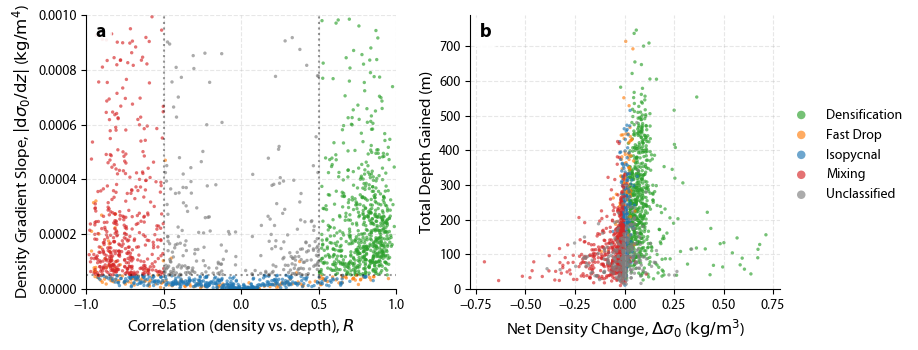

In [8]:
# And Plot the density types

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Adjust font properties globally for clarity
#plt.rcParams.update({'font.size': 9, 'axes.labelsize': 10, 'axes.titlesize': 11})

# PANEL A
for cat, group in df_out.groupby('category'):
    n_count = len(group)
    pct = (n_count / len(df_metrics)) * 100
    label_text = f"{cat}"# ($n={n_count:,}; \\; {pct:.1f}\\%$)"
    print(f"{cat}: n={n_count}, pct={pct:.1f}%")

    ax1.scatter(
        group['r_pear'], 
        group['slope'].abs(), 
        color=color_dict[cat],
        s=6, 
        alpha=0.65, 
        edgecolor='none',
        label=label_text
    )
    
# Visual thresholds indicators on Panel A
ax1.axhline(y=slope_threshold, color='black', linestyle=':', alpha=0.4, label='_nolegend_')
ax1.axvline(x=r_threshold, color='black', linestyle=':', alpha=0.4, label='_nolegend_')
ax1.axvline(x=-r_threshold, color='black', linestyle=':', alpha=0.4, label='_nolegend_')

#PANEL B
for cat, group in df_out.groupby('category'):
    ax2.scatter(
        group['delta_sigma'],          # Change to your exact column name if different
        group['total_depth_gained'],   # Change to your exact column name if different
        color=color_dict[cat],
        s=6, 
        alpha=0.65, 
        edgecolor='none'
    )


# FORMATTING
ax1.set_xlabel(r'Correlation (density vs. depth), $R$')
ax1.set_ylabel(r'Density Gradient Slope, $\left| \mathrm{d}\sigma_0 / \mathrm{d}z \right|$ ($\mathrm{kg/m^{4}}$)')
ax1.set_xlim(-1.0, 1.0)
ax1.set_ylim(0, 0.0010)
ax2.set_xlabel(r'Net Density Change, $\Delta\sigma_0$ ($\mathrm{kg/m^{3}}$)')
ax2.set_ylabel('Total Depth Gained (m)')
ax2.set_ylim(0, 790)

# Single unified legend positioned cleanly at the top of the entire figure
fig.legend(
    loc='center right', 
    bbox_to_anchor=(1.15, 0.5), 
    ncols=1, 
    frameon=True, 
    facecolor='white', 
    edgecolor='none',
    markerscale=2.5,
    fontsize=10
)

for ax in [ax1, ax2]:
    hlp.despine(ax)
    ax.grid(True, linestyle='--', alpha=0.3)
    
plt.tight_layout(rect=[0, 0, 1, 0.90])

# Add subplot labels
letters = ["a", "b"]
for i, ax in enumerate([ax1, ax2]):
        ax.text(
        0.03, 0.97, letters[i], 
        transform=ax.transAxes, 
        fontproperties=font_prop_bold,
        fontsize=14,  
        va='top', 
        ha='left',
        #backgroundcolor='white',
        zorder=100,
        bbox=dict(
            facecolor='white',     # White background
            alpha=0.9,             # 60% opaque (0 = transparent, 1 = solid)
            edgecolor='none',      # No harsh border line around the box
            boxstyle='round,pad=0.3,rounding_size=0.2' # Slightly rounded corners with a bit of padding
        )
    )


# Save figure
plt.savefig(plotpath + 'subduction_classification_regimes.pdf', bbox_inches='tight')
plt.savefig(plotpath + 'subduction_classification_regimes.png', bbox_inches='tight', dpi=300)
plt.show()

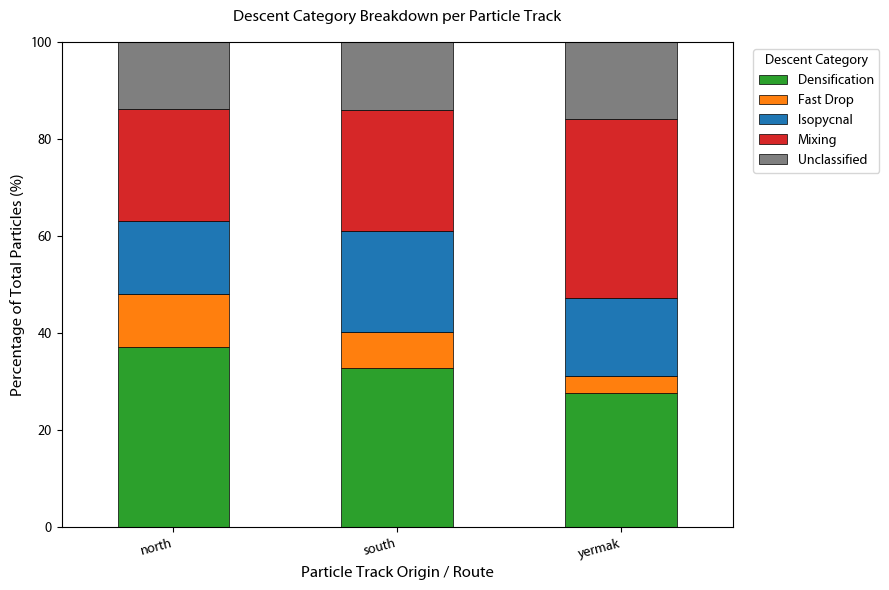

In [49]:
# We use the exact same crosstab_pct table calculated in Step 1
# Pandas has a built-in plotting wrapper for Matplotlib that handles stacked bars perfectly!

# 1. Create the cross-tab table and convert to percentages by row
crosstab = pd.crosstab(df_out['track'], df_out['category'])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# Extract labels and underlying numpy array data
tracks = crosstab_pct.index.tolist()
categories = crosstab_pct.columns.tolist()
data_matrix = crosstab_pct.values

ax = crosstab_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(9, 6),
    color=[color_dict.get(cat, '#7f7f7f') for cat in crosstab_pct.columns], # Maps your exact color dict!
    edgecolor='black',
    linewidth=0.5
)

# Styling adjustments
ax.set_ylabel("Percentage of Total Particles (%)")
ax.set_xlabel("Particle Track Origin / Route")
ax.set_title("Descent Category Breakdown per Particle Track", fontsize=12, pad=15)
ax.set_ylim(0, 100)

# Rotate labels so they don't overlap
plt.xticks(rotation=15, ha='right')

# Add the legend outside the plot area
ax.legend(title="Descent Category", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(plotpath + "Descent-by-Track.png", dpi=300)
plt.show()

## Plot distributions of dynamic properties per type

In [40]:
# Normalise some variables with f
df_out["strain_90_norm"] = df_out["strain_window_90"]/(np.pi *2 / 86164 *2 * np.sin(np.radians(df_out["lat_drop"].values)))
#df_out["ok_weiss_drop_90_10_norm"] = df_out["ok_weiss_drop_90_10"]/(np.pi *2 / 86164 *2 * np.sin(np.radians(df_out["lat_drop"].values)))
df_out["div_90_10_norm"] = df_out["div_90_10"]/(np.pi *2 / 86164 *2 * np.sin(np.radians(df_out["lat_drop"].values)))

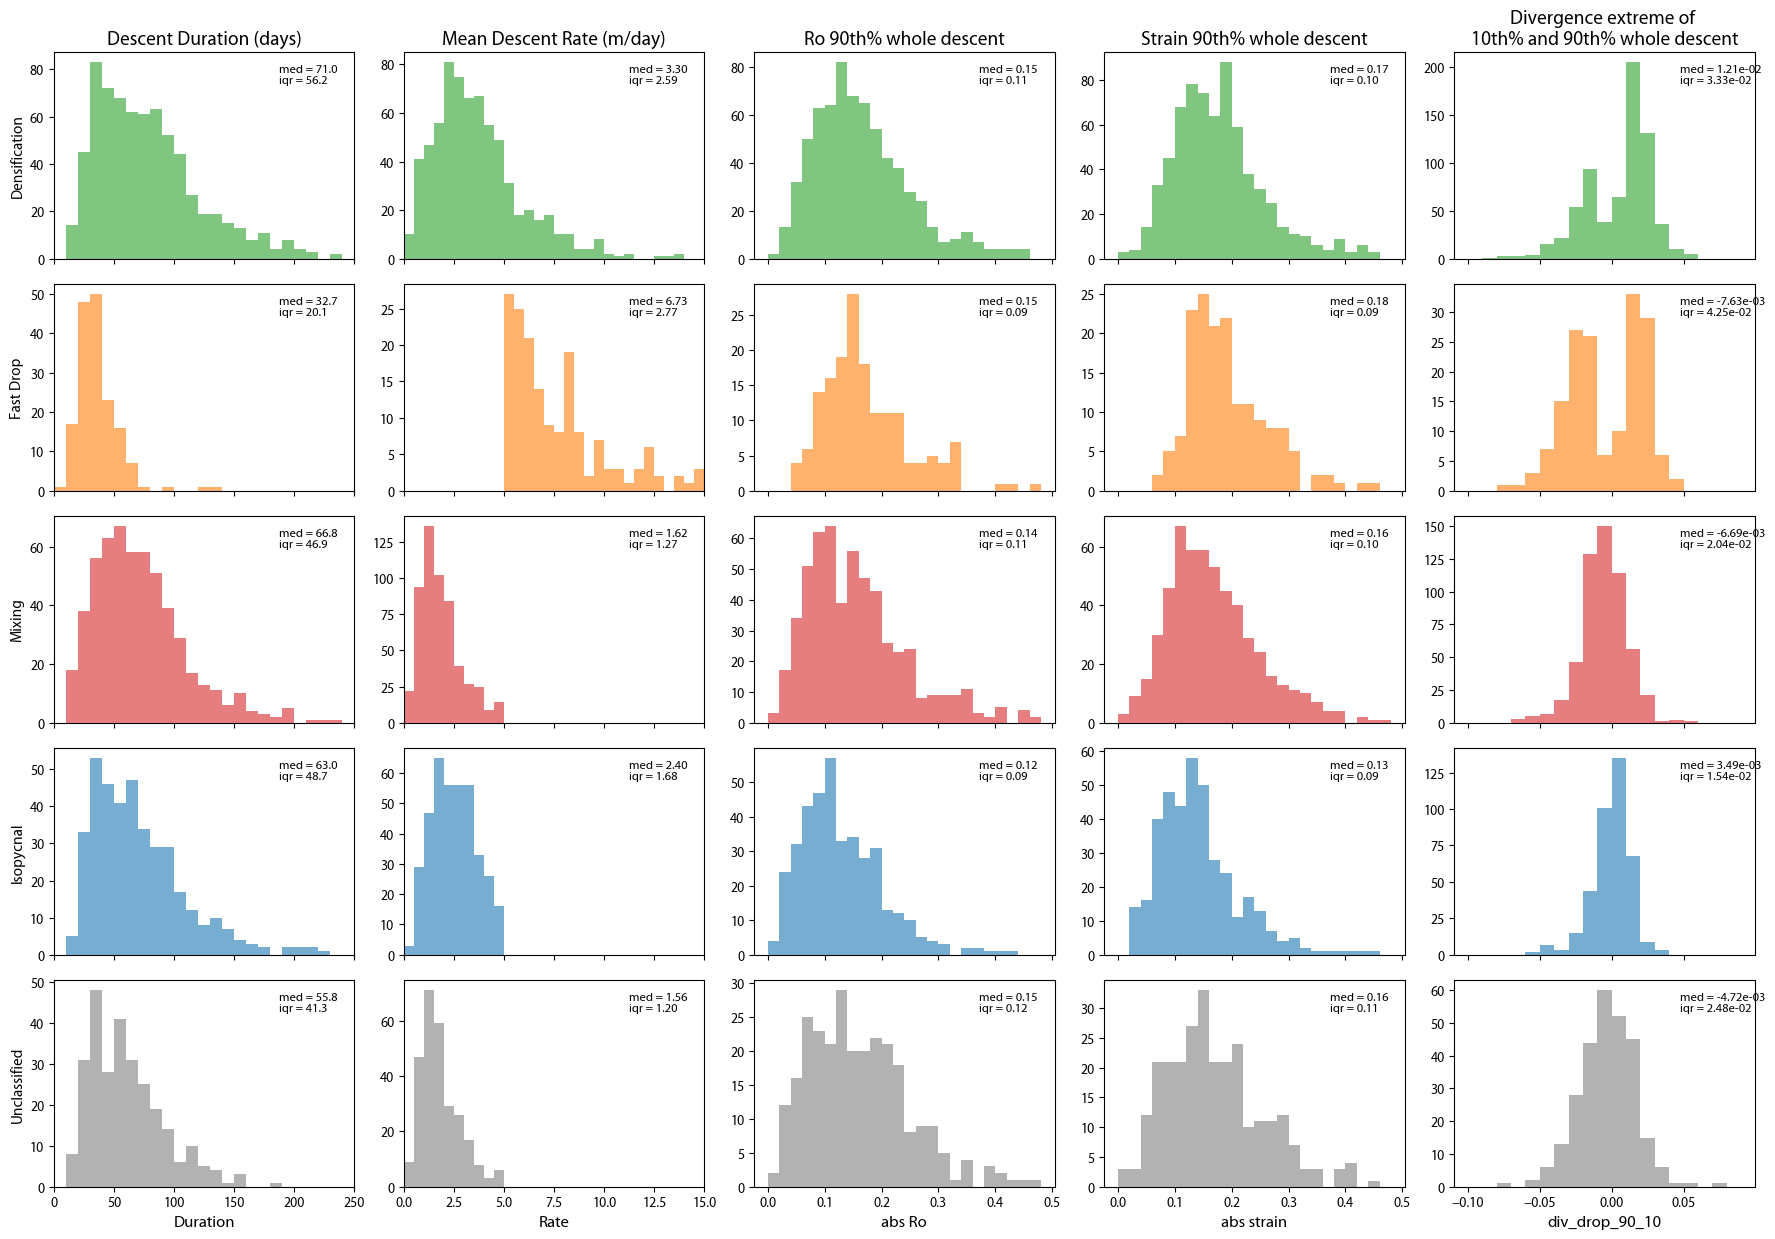

In [44]:
active_cats = [c for c in color_dict if c in df_out["category"].unique()]
n_rows = len(active_cats)
fig, axes = plt.subplots(n_rows, 5, figsize=(18, 2.5 * n_rows), sharex="col", squeeze=False)

# (col_idx, var_name, bins, title, label, use_abs, is_sci)
cols = [
    (0, "descent_duration", np.arange(0, 300, 10), "Descent Duration (days)", "Duration", False, False),
    (1, "mean_descent_rate", np.arange(0, 16, 0.5), "Mean Descent Rate (m/day)", "Rate", False, False),
    (2, "ro_drop_90_10", np.arange(0, 0.5, 0.02), "Ro 90th% whole descent", "abs Ro", True, False),
    #(3, "strain_90_drop", np.arange(0, 6e-5, 4e-6), "strain_max drop", "abs strain", True, True),
    (3, "strain_90_norm", np.arange(0, 0.5, 0.02), "Strain 90th% whole descent", "abs strain", True, False),
    #(4, "ok_weiss_drop_90_10", np.arange(-2e-9, 2e-9, 5e-10), "okobu weiss", "okobu weiss", False, True),
    #(4, "ok_weiss_drop_90_10_norm", np.arange(-2e-5, 2e-5, 5e-6), "okobu weiss", "okobu weiss", False, True),
    #(5, "total_depth_gained", np.arange(0,700,20), "total_depth_gained", "total_depth_gained", False, False),
    (4, "div_90_10_norm", np.arange(-0.1,0.1,1e-2), "Divergence extreme of \n10th% and 90th% whole descent", "div_drop_90_10", False, True),

]

# Loop through the descent categories (ax rows)
for i, cat in enumerate(active_cats):
    axes[i, 0].set_ylabel(cat, fontsize=11, fontweight="bold")

    # Loop trough the variables (ax columns)
    for j, var, bins, title, lbl, use_abs, sci in cols:
        ax = axes[i, j]
        data = abs(df_out[df_out["category"] == cat][var].dropna()) if use_abs else df_out[df_out["category"] == cat][var].dropna()
        ax.hist(data, bins=bins, color=color_dict[cat], alpha=0.6, edgecolor="none")
        
        if i == 0: ax.set_title(title)
        if i == n_rows - 1: ax.set_xlabel(lbl)
        
        if len(data) > 0:
            fmt = ".2e" if sci else ".1f" if j == 0 else ".2f"  # .1f for days, .2f for rates/Ro, .2e for strain
            iqr = np.percentile(data, 75) - np.percentile(data, 25)
            ax.text(0.75, 0.85, f"med = {np.median(data):{fmt}}\niqr = {iqr:{fmt}}", transform=ax.transAxes, fontsize=9)

axes[0, 0].set_xlim(0, 250)
axes[1 if n_rows > 1 else 0, 1].set_xlim(0, 15)
plt.tight_layout()
plt.savefig(plotpath + "hists.png")
plt.show()

## Normalized Time series

In [ ]:

# Define a uniform normalized time grid
normalized_grid = np.linspace(-1, 1, 100)
normalized_records = []

print("Extracting entire descent timelines and calculating PW encounter stages...")

for _, row in tqdm(df_out.iterrows(), total=len(df_out)):
    
    drifter_id  = row['drifter_id']
    release_doy = row['release_doy']
    category    = row['category']
    
    # Extract your specific feature event indices
    t_start = int(row['time_start'])
    t_drop  = int(row['time_drop'])
    t_stop  = int(row['time_stop'])
    t_pw    = int(row['time'])  # The PW encounter index
    
    # Safe check for malformed indices
    if t_stop <= t_start or not (t_start <= t_drop <= t_stop):
        continue
        
    ds_drifter = DS[release_doy].sel(drifter=drifter_id)
    
    # Slice variables across the ENTIRE individual descent length
    ro_slice   = ds_drifter.Ro.values[t_start:t_stop+1]
    str_slice  = ds_drifter.strain.values[t_start:t_stop+1] / ds_drifter.f.values[t_start:t_stop+1]
    div_slice  = ds_drifter.divergence.values[t_start:t_stop+1] / ds_drifter.f.values[t_start:t_stop+1]
    
    depth_full = ds_drifter.depth.values
    w_full     = np.gradient(depth_full) * STEPS_PER_DAY
    w_slice    = w_full[t_start:t_stop+1]
    
    # Map the PW encounter index to the [-1, 1] tau scale
    if t_pw <= t_drop:
        tau_pw = (t_pw - t_drop) / (t_drop - t_start) if (t_drop - t_start) > 0 else np.nan
    else:
        tau_pw = (t_pw - t_drop) / (t_stop - t_drop) if (t_stop - t_drop) > 0 else np.nan

    # Build the original, asymmetric time index for this specific particle
    actual_indices = np.arange(t_start, t_stop + 1)
    particle_time  = np.zeros_like(actual_indices, dtype=float)
    
    left_mask  = actual_indices <= t_drop
    right_mask = actual_indices > t_drop
    
    if (t_drop - t_start) > 0:
        particle_time[left_mask] = (actual_indices[left_mask] - t_drop) / (t_drop - t_start)
    if (t_stop - t_drop) > 0:
        particle_time[right_mask] = (actual_indices[right_mask] - t_drop) / (t_stop - t_drop)

    # Interpolate physical data onto uniform [-1, 1] grid
    def resample(var_slice):
        mask = np.isfinite(var_slice) & np.isfinite(particle_time)
        if mask.sum() < 2: 
            return np.full(100, np.nan)
        f_interp = interp1d(particle_time[mask], var_slice[mask], bounds_error=False, fill_value="clone")
        return f_interp(normalized_grid)

    normalized_records.append({
        "category": category,
        "Ro":       resample(ro_slice),
        "strain":   resample(str_slice),
        "div":      resample(div_slice),
        "w":        resample(w_slice),
        "tau_pw":   tau_pw  # Saved normalized PW time step
    })

Extracting entire descent timelines and calculating PW encounter stages...


100%|██████████| 2107/2107 [00:03<00:00, 551.53it/s]


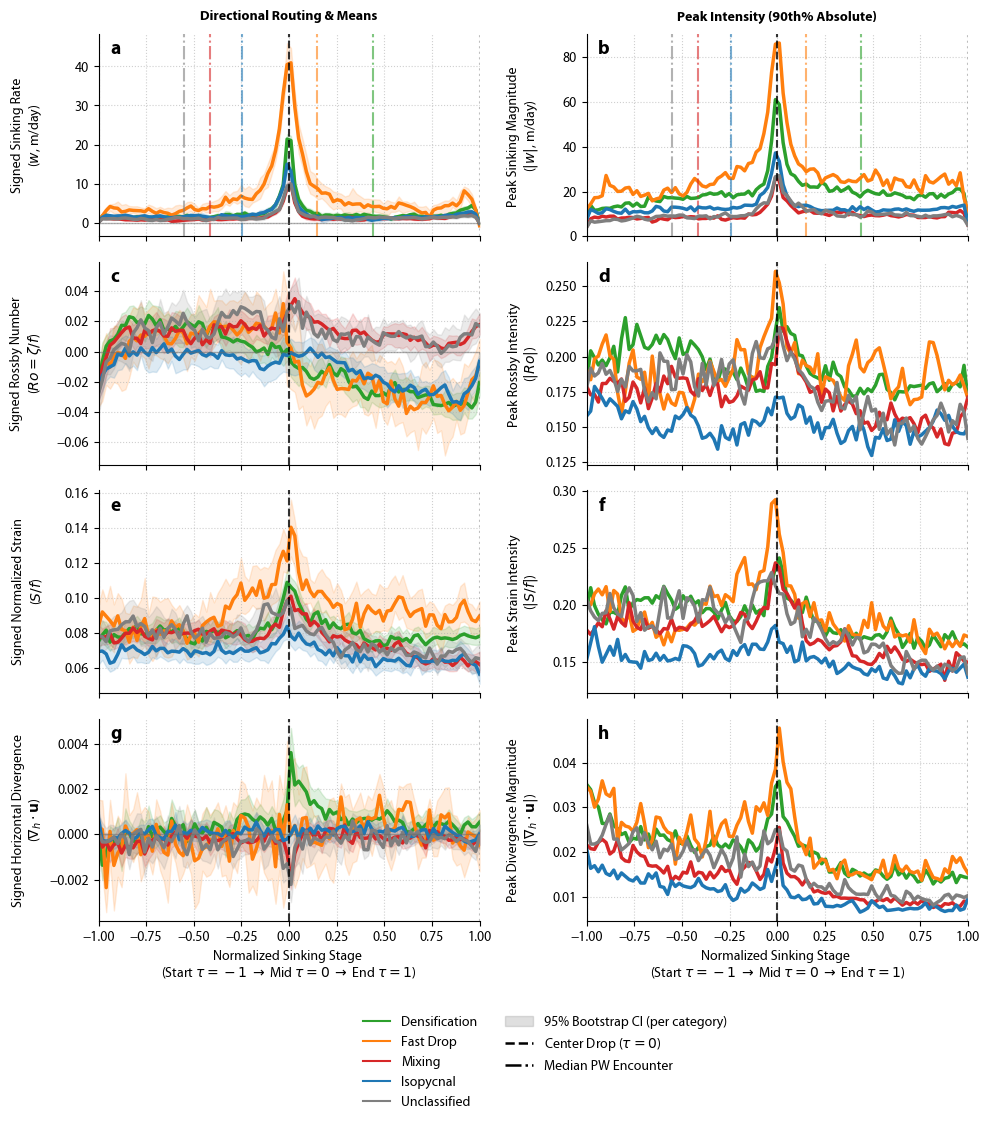

In [15]:

from scipy.stats import bootstrap
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ==============================================================================
# DROP-IN 4x2 PLOT: COL 1 (SIGNED MEDIANS) | COL 2 (90th% ABSOLUTE INTENSITY)
# ==============================================================================
fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True)

variables = ['w', 'Ro', 'strain', 'div']
titles_col1 = [
    'Signed Sinking Rate\n($w$, m/day)', 
    'Signed Rossby Number\n($Ro = \zeta/f$)', 
    'Signed Normalized Strain\n($S/f$)', 
    'Signed Horizontal Divergence\n'+r'($\nabla_h \cdot \mathbf{u}$)'
]
titles_col2 = [
    'Peak Sinking Magnitude \n($|w|$, m/day)', 
    'Peak Rossby Intensity \n($|Ro|$)', 
    'Peak Strain Intensity \n($|S/f|$)', 
    'Peak Divergence Magnitude\n'+r'($|\nabla_h \cdot \mathbf{u}|$)'
]

for row_idx, var in enumerate(variables):
    ax_left  = axes[row_idx, 0]  # Column 1: Signed
    ax_right = axes[row_idx, 1]  # Column 2: Absolute Magnitude
    
    for cat_name, color in color_dict.items():
        # Isolate entries matching the current category
        cat_data = [r for r in normalized_records if r['category'] == cat_name]
        if len(cat_data) < 5: 
            continue
            
        matrix  = np.vstack([r[var] for r in cat_data])
        tau_pws = np.array([r['tau_pw'] for r in cat_data])
        
        # 1. Compute lines
        group_median = np.nanmedian(matrix, axis=0)
        group_abs_90 = np.nanpercentile(np.abs(matrix), 90, axis=0)
        
        # 2. Bootstrapping for 95% CI (Left column only to keep it clean)
        ci_lower = np.zeros(matrix.shape[1])
        ci_upper = np.zeros(matrix.shape[1])
        for step in range(matrix.shape[1]):
            step_data = matrix[:, step]
            clean_step_data = step_data[np.isfinite(step_data)]
            if len(clean_step_data) > 5:
                res = bootstrap((clean_step_data,), np.median, confidence_level=0.95, 
                                method='percentile', n_resamples=500)
                ci_lower[step] = res.confidence_interval.low
                ci_upper[step] = res.confidence_interval.high
            else:
                ci_lower[step] = ci_upper[step] = group_median[step]
        
        # ----------------------------------------------------------------------
        # COLUMN 1: SIGNED MEDIANS (NET TRENDS)
        # ----------------------------------------------------------------------
        ax_left.plot(normalized_grid, group_median, color=color, lw=2.5, 
                     label=f"{cat_name} (n={len(cat_data)})")
        ax_left.fill_between(normalized_grid, ci_lower, ci_upper, color=color, alpha=0.15)
        
        # ----------------------------------------------------------------------
        # COLUMN 2: 90th PERCENTILE ABSOLUTE (PEAK INTENSITY)
        # ----------------------------------------------------------------------
        ax_right.plot(normalized_grid, group_abs_90, color=color, lw=2.5, linestyle="-")
        
        # ----------------------------------------------------------------------
        # SHARED FEATURE: POLAR WATER ENCOUNTERS
        # ----------------------------------------------------------------------
        group_median_pw = np.nanmedian(tau_pws)
        if np.isfinite(group_median_pw) and (-1 <= group_median_pw <= 1) and (ax_left==axes[0,0]):
            # Plot on both columns for easy reference
            ax_left.axvline(x=group_median_pw, color=color, linestyle="-.", lw=1.5, alpha=0.6,
                            label=f"PW Encounter ({cat_name})" if row_idx == 0 else "")
            ax_right.axvline(x=group_median_pw, color=color, linestyle="-.", lw=1.5, alpha=0.6)

    # Panel Formatting Polish
    ax_left.set_ylabel(titles_col1[row_idx], fontsize=10)#, fontweight='bold')
    ax_right.set_ylabel(titles_col2[row_idx], fontsize=10)#, fontweight='bold')
    
    for ax in [ax_left, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.axvline(x=0, color="black", linestyle="--", alpha=0.8, label="Center Drop ($\tau=0$)" if row_idx == 0 and ax == ax_left else "")
        ax.axvline(x=-1, color="gray", linestyle=":", alpha=0.5)
        ax.axvline(x=1, color="gray", linestyle=":", alpha=0.5)
        
    # Baseline lines only make physical sense for signed data containing 0
    if var in ['div', 'w', 'Ro']: 
        ax_left.axhline(y=0, color="dimgray", linestyle="-", alpha=0.5, lw=1)

    hlp.despine(ax_left)
    hlp.despine(ax_right)

# Global Formatting Polish
legend_handles = []

# Add Category Colors dynamically from your color_dict
for cat_name, color in color_dict.items():
    legend_handles.append(mlines.Line2D([0], [0], color=color, label=cat_name))

# Add the Bootstrap Uncertainty Patch (using a generic gray patch)
legend_handles.append(mpatches.Patch(color='gray', alpha=0.25, label='95% Bootstrap CI (per category)'))

# Add the structural black lines representing the line types
legend_handles.append(mlines.Line2D([0], [0], color='black', linestyle='--', lw=1.8, label=r'Center Drop ($\tau=0$)'))
legend_handles.append(mlines.Line2D([0], [0], color='black', linestyle='-.', lw=1.8, label='Median PW Encounter'))

# Column 2 Padding: Add 2 invisible entries to force a 5-row layout
legend_handles.append(mpatches.Patch(color='none', label=''))
legend_handles.append(mpatches.Patch(color='none', label=''))

# Apply the custom handles as a 2-column legend on the first subplot
fig.legend(handles=legend_handles, loc="lower center", ncol=2, 
                  frameon=True, facecolor='white', framealpha=0.9, edgecolor='none', fontsize=10, bbox_to_anchor=(0.55,-0.13))
axes[0, 0].set_title("Directional Routing & Means", fontsize=13, fontproperties=font_prop_bold, pad=10)
axes[0, 1].set_title("Peak Intensity (90th% Absolute)", fontsize=13, fontproperties=font_prop_bold, pad=10)

axes[-1, 0].set_xlabel("Normalized Sinking Stage \n(Start $\\tau=-1$ $\\rightarrow$ Mid $\\tau=0$ $\\rightarrow$ End $\\tau=1$)", fontsize=10)#, fontweight='bold')
axes[-1, 1].set_xlabel("Normalized Sinking Stage \n(Start $\\tau=-1$ $\\rightarrow$ Mid $\\tau=0$ $\\rightarrow$ End $\\tau=1$)", fontsize=10)#, fontweight='bold')

axes[-1, 0].set_xlim(-1, 1)
axes[-1, 1].set_xlim(-1, 1)

letters = ["a", "b", "c", "d", "e", r"f$\,$", "g", "h"]
for i, ax in enumerate(axes[:,:].flatten()):
        ax.text(
        0.03, 0.97, letters[i], 
        transform=ax.transAxes, 
        fontproperties=font_prop_bold,
        fontsize=14,  
        va='top', 
        ha='left',
        #backgroundcolor='white',
        zorder=100,
        #bbox=dict(
        #    facecolor='white',     # White background
        #    alpha=0.9,             # 60% opaque (0 = transparent, 1 = solid)
        #    edgecolor='none',      # No harsh border line around the box
        #    boxstyle='round,pad=0.3,rounding_size=0.2' # Slightly rounded corners with a bit of padding
        #)
    )


fig.align_ylabels()
plt.tight_layout()
plt.savefig(plotpath + f'subduction_classification_dynamics_ts.pdf', bbox_inches='tight')
plt.savefig(plotpath + f'subduction_classification_dynamics_ts.png', bbox_inches='tight', dpi=300)
plt.show()

## Binned Statistics

In [41]:
def plot_binned_mean(x, y, num_bins=40, fig=None, ax1=None):
    from scipy.stats import binned_statistic


    bins = np.linspace(np.min(x), np.max(x), num_bins)

    mean_abs_w, edges, _ = binned_statistic(
        x, np.abs(y),
        statistic='mean',
        bins=bins
    )
    bin_centers = 0.5*(edges[:-1] + edges[1:])

    if fig is None or ax1 is None:
        fig, ax1 = plt.subplots(figsize=(4,3), tight_layout=True)

    ax1.plot(bin_centers, mean_abs_w, color="darkred", linewidth=3)

    # Number of points histogram
    ax2 = ax1.twinx()
    ax2.hist(x, bins=bins, color='grey', alpha=0.2, linewidth=2)
    ax2.set_ylabel("Number of data points", color='grey')

    ax1.plot(bin_centers, mean_abs_w, color="darkred", linewidth=3)
    ax1.yaxis.set_label_position("left")
    ax1.yaxis.set_ticks_position("left")

    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.set_ylim(0,None)

    return fig, (ax1, ax2)

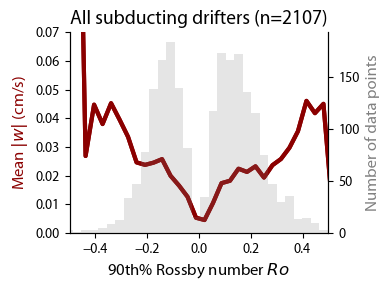

In [44]:
x = df_out["ro_drop_90_10"]
y = df_out["w_mean_drop"]*100

# Create a 2D histogram
fig, (ax1, ax2) = plot_binned_mean(x, y, num_bins=40)

ax1.set_xlabel("90th% Rossby number $Ro$")
ax1.set_ylabel(r"Mean $\vert w \vert$ (cm/s)", color="darkred")

ax1.set_xlim(-0.5,0.5)
ax1.set_ylim(0,0.07)

ax1.set_title(f"All subducting drifters (n={len(df_out)})")
plt.savefig(plotpath + "Binned-statistics_Ro-w_all-groups.png")

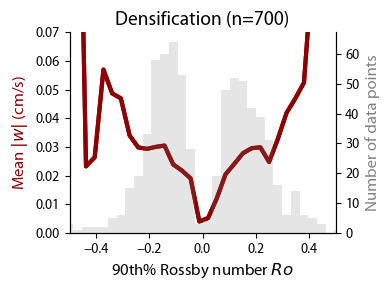

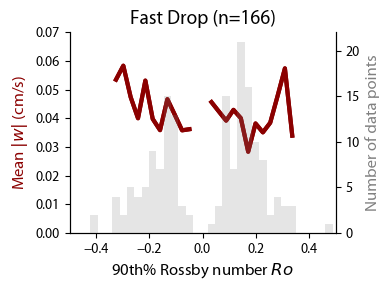

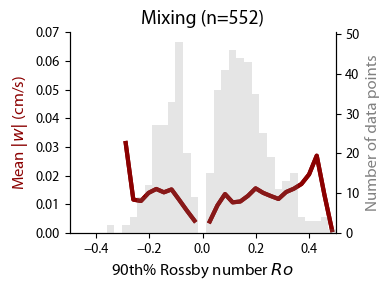

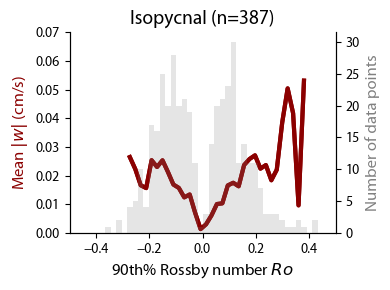

In [ ]:
for cat in categories:
    df_cat = df_out[df_out["category"] == cat]
    x = df_cat["ro_drop_90_10"]
    y = df_cat["w_mean_drop"]*100

    # Create a 2D histogram
    fig, (ax1, ax2) = plot_binned_mean(x, y, num_bins=40)

    ax1.set_xlabel("90th% Rossby number $Ro$")
    ax1.set_ylabel(r"Mean $\vert w \vert$ (cm/s)", color="darkred")#, labelpad=-10)

    ax1.set_xlim(-0.5,0.5)
    ax1.set_ylim(0,0.07)

    ax1.set_title(f"{cat} (n={len(df_cat)})")
    plt.savefig(plotpath + f"Binned-statistics_Ro-w_{cat}.png")

## Some happy LaTex printing

In [14]:
# Helper function to format scientific notation for LaTeX
def format_latex_sci(val):
    if pd.isna(val):
        return "N/A"
    if abs(val) < 0.01 and val != 0:
        # Formats e.g., 4.2e-05 to 4.2 \times 10^{-5}
        str_val = f"{val:.2e}"
        base, exp = str_val.split("e")
        return f"${base} \\times 10^{{{int(exp)}}}$"
    return f"{val:.2f}"


# Helper function to compute Mean, Median, and IQR safely
def get_stats(data):
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    mean = np.mean(data)
    median = np.median(data)
    # IQR = 75th percentile - 25th percentile
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    return mean, median, iqr


# Generate LaTeX Table Code 

active_categories = [
    cat for cat in color_dict.keys() if cat in df_out["category"].unique()
]

# Calculate the total population size to compute percentages accurately
total_samples = len(df_out)

latex_str = []
# Added an 'c' column for the metadata and a vertical divider '|' to separate it from metrics
latex_str.append("\\begin{tabular}{lc|cc|cc|cc|cc}")
latex_str.append("\\hline")
latex_str.append(
    " & & \\multicolumn{2}{c|}{\\textbf{Descent Duration (days)}} & \\multicolumn{2}{c|}{\\textbf{Mean Descent Rate (m/day)}} & \\multicolumn{2}{c|}{\\textbf{Ro Max Drop}} & \\multicolumn{2}{c}{\\textbf{Strain Max Drop}} \\\\"
)
latex_str.append(
    "\\textbf{Category} & \\textbf{N (\\%)} & Median & (IQR) & Median & (IQR) & Median & (IQR) & Median & (IQR) \\\\"
)
latex_str.append("\\hline")

for cat in active_categories:
    group = df_out[df_out["category"] == cat]
    
    # Calculate sample count and overall percentage for this category
    cat_count = len(group)
    cat_pct = (cat_count / total_samples) * 100 if total_samples > 0 else 0

    # Extract arrays matching your script's logic
    dur = group["descent_duration"].dropna()
    rate = group["mean_descent_rate"].dropna()
    ro = abs(group["Ro_90_drop"].dropna())
    strain = abs(group["strain_90_drop"].dropna())

    # Calculate metrics
    m_dur, med_dur, iqr_dur = get_stats(dur)
    m_rate, med_rate, iqr_rate = get_stats(rate)
    m_ro, med_ro, iqr_ro = get_stats(ro)
    m_strain, med_strain, iqr_strain = get_stats(strain)

    # Construct the row with stacked metric notation and the new metadata column
    row_line = (
        f"{cat} & "
        f"{cat_count} ({cat_pct:.1f}\\%) & "
        f"{med_dur:.1f} & ({iqr_dur:.1f}) & "
        f"{med_rate:.2f} & ({iqr_rate:.2f}) & "
        f"{med_ro:.2f} & ({iqr_ro:.2f}) & "
        f"{format_latex_sci(med_strain)} & ({format_latex_sci(iqr_strain)}) \\\\"
    )
    latex_str.append(row_line)

latex_str.append("\\hline")
latex_str.append("\\end{tabular}")

# Print the final result to copy-paste
print("\n".join(latex_str))

\begin{tabular}{lc|cc|cc|cc|cc}
\hline
 & & \multicolumn{2}{c|}{\textbf{Descent Duration (days)}} & \multicolumn{2}{c|}{\textbf{Mean Descent Rate (m/day)}} & \multicolumn{2}{c|}{\textbf{Ro Max Drop}} & \multicolumn{2}{c}{\textbf{Strain Max Drop}} \\
\textbf{Category} & \textbf{N (\%)} & Median & (IQR) & Median & (IQR) & Median & (IQR) & Median & (IQR) \\
\hline
Densification & 700 (33.2\%) & 71.0 & (56.2) & 3.30 & (2.59) & 0.14 & (0.12) & $2.20 \times 10^{-5}$ & ($1.60 \times 10^{-5}$) \\
Fast Drop & 166 (7.9\%) & 32.7 & (20.1) & 6.73 & (2.77) & 0.15 & (0.13) & $2.55 \times 10^{-5}$ & ($1.56 \times 10^{-5}$) \\
Mixing & 552 (26.2\%) & 66.8 & (46.9) & 1.62 & (1.27) & 0.12 & (0.12) & $2.02 \times 10^{-5}$ & ($1.68 \times 10^{-5}$) \\
Isopycnal & 387 (18.4\%) & 63.0 & (48.7) & 2.40 & (1.68) & 0.10 & (0.10) & $1.60 \times 10^{-5}$ & ($1.30 \times 10^{-5}$) \\
Unclassified & 302 (14.3\%) & 55.8 & (41.3) & 1.56 & (1.20) & 0.12 & (0.12) & $1.80 \times 10^{-5}$ & ($1.81 \times 10^{-5}$) \\
\hl

## Plotting Maps by Type

In [50]:
 # Seasons
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"
    
df_out["season_drop"] = df_out["datetime_drop"].dt.month.apply(assign_season)
df_out["season_start"] = df_out["datetime_start"].dt.month.apply(assign_season)

In [46]:
sys.path.append("/albedo/home/quraus001/FESOM-FS-subduction/functions/")
import FESOM_processing as fprc
import FESOM_plotting as fplt


# Load bathymetry data
ds_bath = xr.open_dataset("/albedo/work/user/quraus001/bath/ETOPO_2022_v1_60s_N90W180_bed.nc")
# select only reagion of interest
ds_bath = ds_bath.sel(lon=slice(-40, 40), lat=slice(70, 90))


# Processing code for the FESOM sea ice data (uncomment if you want to reprocess the original data, but it takes a bit of time)
#from cdo import Cdo
#cdo = Cdo()
#file =  "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.ice.mean.sub.nc"
# make seasonal means
#cdo.seasmean(input=file, output="/albedo/work/user/quraus001/FESOM_particles/result/processed_results/Arc40.2006.ice.mean.seasonal.sub.nc")

# Load FESOM sea ice data
mesh = pf.load_mesh("/albedo/home/quraus001/Arc08_sub/")
ds_ice_seasonal = fprc.load_FESOM_data_with_grid("/albedo/home/quraus001/Arc08_sub/", "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/Arc40.2006.ice.mean.seasonal.sub.nc")
ice_colors = ["#3e9ddc", "#3ec2dc", "#3edcd2", "#3edca5"]

/albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
3
The usepickle == True)
The pickle file for python 3 exists.
The mesh will be loaded from /albedo/home/quraus001/Arc08_sub/pickle_mesh_py3


In [66]:
def build_wedge_subplots(figsize=(10, 4), nrows=2, ncols=2, extent=[-25, 25, 75, 83], gridlines=True, show_bottom=True, show_right=True):

    lon_min, lon_max, lat_min, lat_max = extent
    projection = ccrs.AlbersEqualArea(
                central_longitude=(lon_min+lon_max)/2,
                central_latitude=(lat_min+lat_max)/2,
                standard_parallels=(lat_min, lat_max)
            )

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection': projection})
    _ = wm.wedge_map_boudary(land_color="grey", ax=axs.flatten())
    for ax in axs.flatten():
        wm.add_wedge_gridlines(ax, show_top=False, show_bottom=show_bottom, show_left=False, show_right=show_right, lines=gridlines)

    return fig, axs

In [52]:
def scatter_heatmap_on_hexbin(
    ax, X, Y, C, 
    gridsize=30,           # <-- Lowercase to match matplotlib standard
    extent=None,           # <-- Added to lock the grid spatial limits
    cmap='viridis', 
    vmin=None, 
    vmax=None, 
    cmap_extend=None, 
    boundaries=None,       
    solid_color=None,      
    stats_func=np.median, 
    clabel="Median Value",
    global_max_count=None,  
    show_legend=True,
    show_colorbar=True        
):
    

    # 1. Run the master hexbin to grab centers and calculated means
    # Passing the exact same gridsize and extent forces alignment across subplots!
    hb = ax.hexbin(
        X, Y, C=C,      
        reduce_C_function=stats_func,       
        gridsize=gridsize,                     
        extent=extent,                    # <-- CRITICAL: Forces identical grid geometry
        transform=ccrs.PlateCarree(),
        mincnt=1,
        visible=False
    )

    x_centers = hb.get_offsets()[:, 0]
    y_centers = hb.get_offsets()[:, 1]
    bin_means = hb.get_array()

    print(f"Data range: x[{x_centers.min():.1f}, {x_centers.max():.1f}], y[{y_centers.min():.1f}, {y_centers.max():.1f}]")
    print(f"Axis limits: {ax.get_extent(crs=ax.projection)}")

    # 2. Project your raw data coordinates into the map coordinate system
    raw_projected_pts = ax.projection.transform_points(ccrs.PlateCarree(), X, Y)
    raw_x = raw_projected_pts[:, 0]
    raw_y = raw_projected_pts[:, 1]

    # 3. Use a KDTree to query which hex center each raw data point belongs to
    hex_centers = np.column_stack((x_centers, y_centers))
    raw_data_points = np.column_stack((raw_x, raw_y))

    tree = KDTree(hex_centers)
    _, closest_hex_indices = tree.query(raw_data_points)

    bin_counts = np.bincount(closest_hex_indices, minlength=len(x_centers))

    # 4. Scale your point marker sizes using GLOBAL max count if provided
    max_size = 70
    scaling_max = global_max_count if global_max_count is not None else bin_counts.max()
    
    if scaling_max == 0:
        scaling_max = 1

    sizes = 5 + (bin_counts / scaling_max) * max_size

    # 5. Color and Norm Handling logic
    sc_kwargs = {
        's': sizes,
        'edgecolor': 'black',
        'linewidth': 0.5,
        'alpha': 0.9,
        'zorder': 100
    }

    if solid_color is not None:
        sc_kwargs['color'] = solid_color
        show_colorbar = False
    elif boundaries is not None:
        cmap_obj = plt.get_cmap(cmap)
        norm = mcolors.BoundaryNorm(boundaries, ncolors=cmap_obj.N, extend=cmap_extend or 'neither')
        sc_kwargs['c'] = bin_means
        sc_kwargs['cmap'] = cmap_obj
        sc_kwargs['norm'] = norm
    else:
        sc_kwargs['c'] = bin_means
        sc_kwargs['cmap'] = cmap
        sc_kwargs['vmin'] = vmin
        sc_kwargs['vmax'] = vmax

    sc = ax.scatter(x_centers, y_centers, **sc_kwargs, transform=ax.projection)# added transform

    if show_colorbar:
        plt.colorbar(sc, ax=ax, label=clabel, extend=cmap_extend)

    # --- Build the Size Legend ---
    if show_legend:
        legend_counts = [
            max(1, int(scaling_max * 0.05)),
            max(2, int(scaling_max * 0.50)),
            int(scaling_max)
        ]
        legend_counts = sorted(list(set(legend_counts)))
        
        legend_markers = []
        for count in legend_counts:
            label_text = f"{count} event" if count == 1 else f"{count} events"
            size_formula = 5 + (count / scaling_max) * max_size
            
            marker = ax.scatter(
                [], [],
                s=size_formula,
                color='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=0.9,
                label=label_text
            )
            legend_markers.append(marker)

        leg = ax.legend(
            handles=legend_markers,
            title="Sample Size",
            loc="upper left",
            frameon=True,
            facecolor='white',
            edgecolor='none',
            scatterpoints=1,
            bbox_to_anchor=(0.9, 1)
        )
        leg.set_zorder(100)

In [53]:
timing = "drop"

# --- 1. RUN YOUR OLD SNIPPET FOR GLOBAL GRID parameters ---
lon_lims = [-25, 25]
lat_lims = [75, 83]

lons_edge = np.concatenate([np.linspace(lon_lims[0], lon_lims[1], 50), np.full(50, lon_lims[1]), np.linspace(lon_lims[1], lon_lims[0], 50), np.full(50, lon_lims[0])])
lats_edge = np.concatenate([np.full(50, lat_lims[0]), np.linspace(lat_lims[0], lat_lims[1], 50), np.full(50, lat_lims[1]), np.linspace(lat_lims[1], lat_lims[0], 50)])

equal_area_crs = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)
boundary_projected = equal_area_crs.transform_points(ccrs.PlateCarree(), lons_edge, lats_edge)
X_MIN, X_MAX = boundary_projected[:, 0].min(), boundary_projected[:, 0].max()
Y_MIN, Y_MAX = boundary_projected[:, 1].min(), boundary_projected[:, 1].max()

X_RANGE_M = X_MAX - X_MIN
GLOBAL_GRIDSIZE = int(X_RANGE_M / 75000)
GLOBAL_EXTENT = [X_MIN, X_MAX, Y_MIN, Y_MAX]

# --- 2. PRE-CALCULATE GLOBAL MAX DENSITY (WITH THE FIXED GRID) ---
fig_temp, ax_temp = plt.subplots(subplot_kw={'projection': equal_area_crs})
global_max = 0

for cat in df_out["category"].unique():
    df_category = df_out[df_out["category"] == cat]
    if len(df_category) == 0: 
        continue
        
    hb_temp = ax_temp.hexbin(
        df_category[f"lon_{timing}"].values, 
        df_category[f"lat_{timing}"].values, 
        gridsize=GLOBAL_GRIDSIZE,   # Use master grid size
        extent=GLOBAL_EXTENT,       # Use master bounds
        transform=ccrs.PlateCarree(),
        mincnt=1
    )
    
    counts = hb_temp.get_array()
    if len(counts) > 0 and counts.max() > global_max:
        global_max = counts.max()
    
    print(f"Setting global max to {global_max}")

plt.close(fig_temp)

Setting global max to 37.0
Setting global max to 37.0
Setting global max to 37.0
Setting global max to 37.0
Setting global max to 37.0


In [54]:
target_projection = ccrs.AlbersEqualArea(
    central_longitude=0, central_latitude=79, standard_parallels=(75, 83)
)

# 2. Calculate your Global Grid bounds (The "Master Extent")
# Do this in the SAME projection you use for the final plots
lons = [-25, 25, 25, -25]
lats = [74, 74, 83, 83]
pts = target_projection.transform_points(ccrs.PlateCarree(), np.array(lons), np.array(lats))

GLOBAL_EXTENT = [pts[:, 0].min(), pts[:, 0].max(), pts[:, 1].min(), pts[:, 1].max()]
#GLOBAL_GRIDSIZE = 30 # Or calculated dynamically based on plot size

Data range: x[-331997.7, 456496.8], y[-396677.1, 244357.5]
Axis limits: (-700764.899469575, 700764.899469575, -388601.15612249397, 519086.6320031849)
Data range: x[-82999.4, 456496.8], y[-396677.1, 244357.5]
Axis limits: (-700764.899469575, 700764.899469575, -388601.15612249397, 519086.6320031849)
Data range: x[-331997.7, 414997.1], y[-396677.1, 290145.7]
Axis limits: (-700764.899469575, 700764.899469575, -388601.15612249397, 519086.6320031849)
Data range: x[-331997.7, 331997.7], y[-396677.1, 290145.7]
Axis limits: (-700764.899469575, 700764.899469575, -388601.15612249397, 519086.6320031849)


/tmp/ipykernel_2124316/3300458789.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat[f'month_{timing}'] = df_cat[f'datetime_{timing}'].dt.month
/tmp/ipykernel_2124316/3300458789.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat[f'month_{timing}'] = df_cat[f'datetime_{timing}'].dt.month
/tmp/ipykernel_2124316/3300458789.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

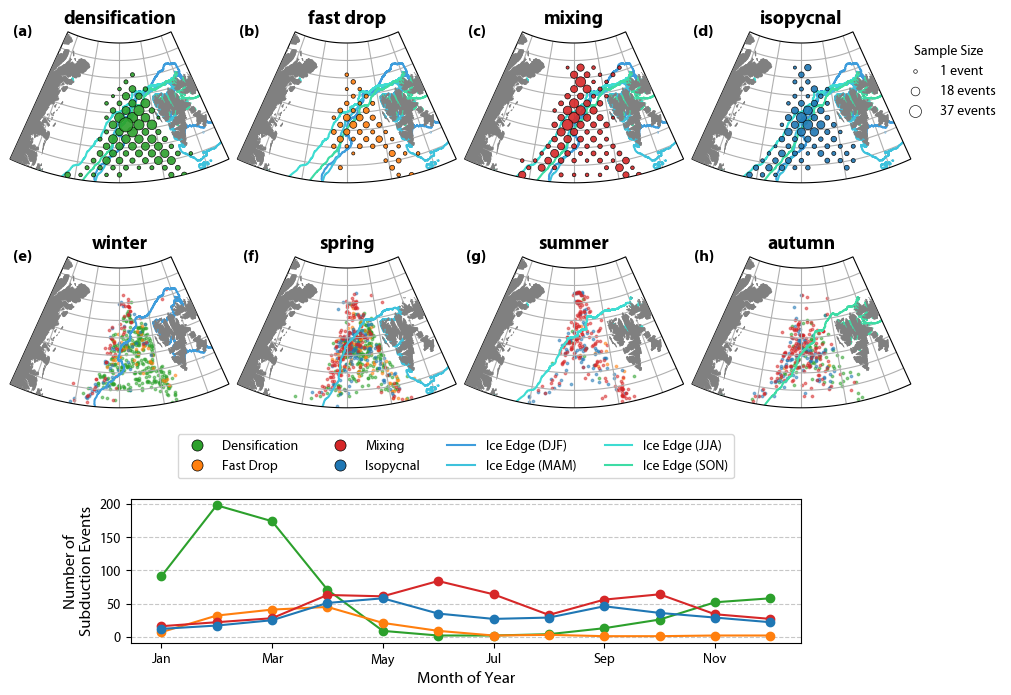

In [64]:
import cartopy.feature as cfeature

fig, axs = build_wedge_subplots(ncols=4, nrows=2, figsize=(10,4.5), gridlines=True, show_right=False, show_bottom=False)
for i, (ax, cat) in enumerate(zip(axs[0,:], ['Densification', 'Fast Drop', 'Mixing', 'Isopycnal'])):
    # group by season_drop
    df_category = df_out[df_out["category"] == cat]
    #plf.add_wedge_gridlines(ax)
    if i ==3:
        show_legend=True
    else:       
        show_legend=False


    scatter_heatmap_on_hexbin(ax, df_category[f"lon_{timing}"].values, df_category[f"lat_{timing}"].values, np.full(len(df_category), 1), 
                              solid_color=color_dict[cat], gridsize=GLOBAL_GRIDSIZE,      # <-- Pass master grid size
                                extent=GLOBAL_EXTENT,          # <-- Pass master extent limits
                                stats_func=lambda x: int(scipy.stats.mode(x)[0]),
                                global_max_count=global_max,   # <-- Pass master size ceiling
                                show_legend=show_legend)


    ax.set_title(f"{cat.lower()}", fontproperties=font_prop_bold, fontsize=14)

#plt.colorbar(sc, ax=axs)
    if True:
        for s in range(4):
            # Ice edge — one contour per month of this season
            ice_vals = ds_ice_seasonal.area.isel(time=s).fillna(0).values
            #color = month_colors[month_num]
            ax.tricontour(
                mesh.x2, mesh.y2, ice_vals,
                levels=[0.15], colors=[ice_colors[s]], linewidths=1.5,
                transform=ccrs.PlateCarree(),#, zorder=4,
            )
import scipy.stats

seasons_order = ["winter", "spring", "summer", "autumn"]
for s, (ax, season) in enumerate(zip(axs[1,:], seasons_order)):
    df_season = df_out[df_out[f"season_{timing}"] == season.capitalize()]
    
    if len(df_season) == 0:
        print(f"No data for season: {season}, skipping subplot.")
        continue
    else:
        for cat, group in df_season.groupby('category'):
            if not cat == "Unclassified":
                sc = ax.scatter(group[f"lon_{timing}"], group[f"lat_{timing}"], color=color_dict[cat], transform=ccrs.PlateCarree(), s=3, alpha=0.5)

    # Ice edge — one contour per month of this season
    ice_vals = ds_ice_seasonal.area.isel(time=s).fillna(0).values
    ax.tricontour(
        mesh.x2, mesh.y2, ice_vals,
        levels=[0.15], colors=[ice_colors[s]], linewidths=1.5,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(f"{season}", fontproperties=font_prop_bold, fontsize=14)


months_season = ["DJF", "MAM", "JJA", "SON"]
for cat in ['Densification', 'Fast Drop', 'Mixing', 'Isopycnal']:
    plt.scatter([], [], color=color_dict[cat], label=cat)  
for s in range(4):
    plt.plot([], [], color=ice_colors[s], label=f'Ice Edge ({months_season[s]})')

from matplotlib.lines import Line2D

# 1. Initialize an empty list for your custom handles
custom_handles = []

# 2. Add the Category Scatter Markers (Row 1 & Row 2 categories)
for cat in ['Densification', 'Fast Drop', 'Mixing', 'Isopycnal']:
    handle = Line2D(
        [0], [0], 
        marker='o',                   # Circular marker like a scatter point
        color='none',                 # No connecting line
        markerfacecolor=color_dict[cat], 
        markeredgecolor='black',       # Match the black edge from hexbin
        markeredgewidth=0.5,
        markersize=8,                 # Set a clean standard size
        label=cat
    )
    custom_handles.append(handle)

# 3. Add the Ice Edge Contour Lines (if you use them)
months_season = ["DJF", "MAM", "JJA", "SON"]
for s in range(4):
    handle = Line2D(
        [0], [0], 
        linestyle='-',                # Solid line style
        color=ice_colors[s], 
        linewidth=1.5,
        label=f'Ice Edge ({months_season[s]})'
    )
    custom_handles.append(handle)

# Add it outside your loops to the overall figure layout
fig.legend(
    handles=custom_handles,
    loc='lower center', 
    ncol=4, 
    bbox_to_anchor=(0.45, -0.1),
    frameon=True,
    facecolor='white'
)

# Add letters to subplots
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', "(g)", "(h)"]
for ax, label in zip(axs.flatten(), subplot_labels):
    ax.add_feature(cfeature.LAND, facecolor="grey", zorder=4)
    ax.text(0.1, 1.05, label, transform=ax.transAxes, fontsize=12, fontproperties=font_prop_bold, va='top', ha='right')


left = 0.125   # Aligns roughly with standard left margins
bottom = -0.45  # Placed low on the figure
width = 0.67  # Stretches across the width
height = 0.32   # Makes it a slim, long axis

# Add the time series axis to the figure
long_ax = fig.add_axes([left, bottom, width, height])

for cat in ['Densification', 'Fast Drop', 'Mixing', 'Isopycnal']:
    df_cat = df_out[df_out["category"] == cat]
    df_cat[f'month_{timing}'] = df_cat[f'datetime_{timing}'].dt.month
    season_counts = df_cat.groupby(f'month_{timing}').size().reindex(range(1,13), fill_value=0)
    long_ax.plot(season_counts.index, season_counts.values, marker='o', label=cat, color=color_dict[cat])

long_ax.set_xlabel('Month of Year')
long_ax.set_xticks(ticks=range(1,13,2), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][::2])
long_ax.set_ylabel('Number of\nSubduction Events')
long_ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][::2])
long_ax.grid(axis='y', linestyle='--', alpha=0.7)


plotpath = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/paper/"
plt.savefig(plotpath + f'subduction_classification_regimes_spatial_{timing}_ts.pdf', bbox_inches='tight')
plt.savefig(plotpath + f'subduction_classification_regimes_spatial_{timing}_ts.png', bbox_inches='tight', dpi=300)
plt.show()

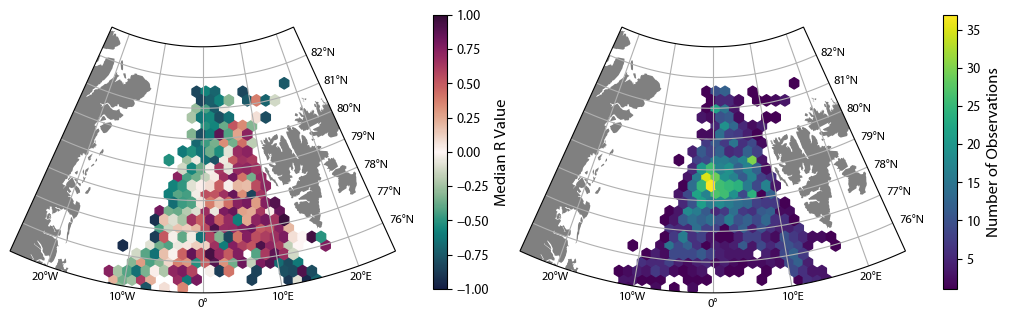

In [72]:
import matplotlib.pyplot as plt

# Create a 2-panel figure side-by-side using the same map projection
fig, axs = build_wedge_subplots(ncols=2, nrows=1)

ax1, ax2 = axs[0], axs[1]

# --- Panel 1: The Mean ---
hb_mean = ax1.hexbin(
    df_out["lon_drop"], 
    df_out["lat_drop"], 
    C=df_out["r_pear"],      # The values to aggregate
    reduce_C_function=np.median,       # Calculate the mean inside each bin
    gridsize=30,                     # Adjust this to change bin size (higher = smaller bins)
    cmap=cmo.cm.curl, 
    vmin=-1, 
    vmax=1, 
    transform=ccrs.PlateCarree(),
    mincnt=1                         # Hides empty bins so they don't block the map
)
plt.colorbar(hb_mean, ax=ax1, label="Median R Value", shrink=0.7)

# --- Panel 2: The Sample Size (Count) ---
hb_count = ax2.hexbin(
    df_out["lon_drop"], 
    df_out["lat_drop"], 
    gridsize=30,                     # Adjust this to change bin size (higher = smaller bins)
    cmap="viridis", 
    transform=ccrs.PlateCarree(),
    mincnt=1                         # Hides empty bins so they don't block the map
)

plt.colorbar(hb_count, ax=ax2, label="Number of Observations", shrink=0.7)
plt.savefig(plotpath + f'subduction-locations-total.png', bbox_inches='tight', dpi=300)
